# 06 - Model Training

## Objective
Train and compare multiple ML models to forecast Lahore AQI one hour ahead.

## Models
1. Baseline (Persistence)
2. Ridge Regression
3. Random Forest
4. XGBoost
5. LSTM (Deep Learning)

## Target
Given features at time t, predict AQI at time t+1

## Evaluation Metrics
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (R-Squared)

## Data Source
Hopsworks Feature Store → lahore_air_quality_features

In [1]:
# ═══════════════════════════════════════════════════════════
# ALL IMPORTS
# ═══════════════════════════════════════════════════════════

import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Core ──────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Hopsworks ─────────────────────────────────────────────
import hopsworks
from dotenv import load_dotenv

# ── Sklearn ───────────────────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ── XGBoost ───────────────────────────────────────────────
import xgboost as xgb

# ── TensorFlow / Keras ────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

# ── Visualization ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Model Saving ──────────────────────────────────────────
import joblib

# ── Reproducibility ───────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

# ── Output Directories ────────────────────────────────────
MODEL_DIR  = Path("models")
OUTPUT_DIR = Path("data/processed/lahore")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Verification ──────────────────────────────────────────
print("=" * 50)
print("IMPORTS VERIFICATION")
print("=" * 50)
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("sklearn     : OK")
print("xgboost     :", xgb.__version__)
print("tensorflow  :", tf.__version__)
print("seaborn     :", sns.__version__)
print("matplotlib  : OK")
print("joblib      : OK")
print("MODEL_DIR   :", MODEL_DIR)
print("OUTPUT_DIR  :", OUTPUT_DIR)
print("=" * 50)
print("All imports successful. Safe to run all cells.")

IMPORTS VERIFICATION
numpy       : 2.4.6
pandas      : 2.3.3
sklearn     : OK
xgboost     : 3.2.0
tensorflow  : 2.21.0
seaborn     : 0.13.2
matplotlib  : OK
joblib      : OK
MODEL_DIR   : models
OUTPUT_DIR  : data\processed\lahore
All imports successful. Safe to run all cells.


In [2]:
load_dotenv()

HOPSWORKS_API_KEY = os.getenv("HOPSWORKS_API_KEY")

if not HOPSWORKS_API_KEY:
    raise ValueError(
        "HOPSWORKS_API_KEY was not found in the .env file."
    )

print("Hopsworks API key loaded successfully.")

Hopsworks API key loaded successfully.


In [3]:
import hopsworks

project = hopsworks.login(
    host="eu-west.cloud.hopsworks.ai",
    project="internship10P",
    api_key_value=HOPSWORKS_API_KEY,
    engine="python",
    cert_folder=r"D:\talha\Pearls_AQI_Predictor\hopsworks-certs"
)

print("Connected to Hopsworks successfully.")
print("Project:", project.name)

2026-08-18 21:29:17,759 INFO: Initializing external client
2026-08-18 21:29:17,761 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-18 21:29:23,611 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/42187
Connected to Hopsworks successfully.
Project: internship10P


In [4]:
feature_store = project.get_feature_store()

print("Feature Store connected successfully.")

Feature Store connected successfully.


In [5]:
# ── Get Feature Group ────────────────────────────
feature_group = feature_store.get_feature_group(
    name="lahore_air_quality_features",
    version=1
)

print("Feature Group loaded.")
print("Name   :", feature_group.name)
print("Version:", feature_group.version)

Feature Group loaded.
Name   : lahore_air_quality_features
Version: 1


In [6]:
# ── Read Data ────────────
print("Reading data from Hopsworks...")

lahore_features = feature_group.read(
    read_options={"use_hive": True}
)

# Sort chronologically
lahore_features["datetime"] = pd.to_datetime(
    lahore_features["datetime"]
)

lahore_features = (
    lahore_features
    .sort_values("datetime")
    .reset_index(drop=True)
)

print("Data loaded successfully.")
print("Shape:", lahore_features.shape)
print("Start:", lahore_features["datetime"].min())
print("End  :", lahore_features["datetime"].max())

display(lahore_features.head(3))

Reading data from Hopsworks...
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (10.84s) 
Data loaded successfully.
Shape: (22608, 30)
Start: 2024-01-02 00:00:00
End  : 2026-07-31 23:00:00


,datetime,temperature_2m,relative_humidity_2m,surface_pressure,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,pm2_5,pm10,...,hour_sin,hour_cos,month_sin,month_cos,aqi_change_rate,aqi_lag_1h,aqi_lag_24h,aqi_rolling_mean_6h,aqi_rolling_std_6h,pm25_rolling_mean_6h
0,2024-01-02 00:00:00,6.15,99.31226,992.20780,0.0,34.0,5.692099,214.69522,253.3,363.2,...,0.000000,1.000000,0.5,0.866025,-0.34585,265.12085,272.10837,265.722912,0.729160,236.816667
1,2024-01-02 01:00:00,5.40,99.65353,991.74695,0.0,100.0,6.369050,227.29063,248.7,357.6,...,0.258819,0.965926,0.5,0.866025,-0.31254,264.77500,272.72916,265.349295,0.699532,244.500000
2,2024-01-02 02:00:00,5.00,99.30589,991.61150,0.0,100.0,4.104631,254.74483,234.2,336.2,...,0.500000,0.866025,0.5,0.866025,-0.50409,264.46246,273.39163,264.956248,0.709747,246.350000


In [7]:
print("=" * 60)
print("DATA VALIDATION BEFORE TRAINING")
print("=" * 60)

print("Shape:              ", lahore_features.shape)
print("Missing values:     ", lahore_features.isnull().sum().sum())
print("Duplicate datetime: ", lahore_features["datetime"].duplicated().sum())

intervals = (
    lahore_features["datetime"]
    .diff()
    .dropna()
)

non_hourly = (intervals != pd.Timedelta(hours=1)).sum()
print("Non-hourly gaps:    ", non_hourly)
print("=" * 60)

DATA VALIDATION BEFORE TRAINING
Shape:               (22608, 30)
Missing values:      0
Duplicate datetime:  0
Non-hourly gaps:     0


In [8]:
# Target: AQI one hour into the future
lahore_features["target_aqi_1h"] = (
    lahore_features["us_aqi"].shift(-1)
)

# Drop the last row (no future AQI available)
lahore_features = (
    lahore_features
    .dropna(subset=["target_aqi_1h"])
    .reset_index(drop=True)
)

print("Target column created.")
print("Shape after target creation:", lahore_features.shape)

# Verify
display(
    lahore_features[
        ["datetime", "us_aqi", "target_aqi_1h"]
    ].head(10)
)

Target column created.
Shape after target creation: (22607, 31)


,datetime,us_aqi,target_aqi_1h
0,2024-01-02 00:00:00,264.77500,264.46246
1,2024-01-02 01:00:00,264.46246,263.95837
2,2024-01-02 02:00:00,263.95837,263.74588
3,2024-01-02 03:00:00,263.74588,264.17505
4,2024-01-02 04:00:00,264.17505,264.27502
5,2024-01-02 05:00:00,264.27502,265.65000
6,2024-01-02 06:00:00,265.65000,266.87082
7,2024-01-02 07:00:00,266.87082,267.84167
8,2024-01-02 08:00:00,267.84167,268.54166
9,2024-01-02 09:00:00,268.54166,268.75415


In [9]:
TARGET = "target_aqi_1h"

FEATURE_COLUMNS = [
    # Weather
    "temperature_2m",
    "relative_humidity_2m",
    "surface_pressure",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",

    # Pollutants
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",

    # Current AQI
    "us_aqi",

    # Temporal features
    "hour",
    "day",
    "month",
    "day_of_week",
    "is_weekend",

    # Cyclical encoding
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",

    # Engineered features
    "aqi_change_rate",
    "aqi_lag_1h",
    "aqi_lag_24h",
    "aqi_rolling_mean_6h",
    "aqi_rolling_std_6h",
    "pm25_rolling_mean_6h"
]

# Verify all columns exist
missing_cols = [
    col for col in FEATURE_COLUMNS
    if col not in lahore_features.columns
]

if missing_cols:
    print("WARNING - Missing columns:")
    for col in missing_cols:
        print("  -", col)
else:
    print("All feature columns found.")

X = lahore_features[FEATURE_COLUMNS].copy()
y = lahore_features[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing in X:", X.isnull().sum().sum())
print("Missing in y:", y.isnull().sum())

All feature columns found.
X shape: (22607, 29)
y shape: (22607,)
Missing in X: 0
Missing in y: 0


In [10]:
n = len(lahore_features)

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.85

train_end = int(n * TRAIN_RATIO)
val_end   = int(n * VAL_RATIO)

# ML datasets (no scaling for tree-based models)
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("=" * 60)
print("TIME-BASED SPLIT")
print("=" * 60)
print(f"Total rows : {n}")
print(f"Train rows : {len(X_train)}")
print(f"Val rows   : {len(X_val)}")
print(f"Test rows  : {len(X_test)}")
print()
print(
    "Train period:",
    lahore_features["datetime"].iloc[0].date(),
    "→",
    lahore_features["datetime"].iloc[train_end - 1].date()
)
print(
    "Val period  :",
    lahore_features["datetime"].iloc[train_end].date(),
    "→",
    lahore_features["datetime"].iloc[val_end - 1].date()
)
print(
    "Test period :",
    lahore_features["datetime"].iloc[val_end].date(),
    "→",
    lahore_features["datetime"].iloc[-1].date()
)
print("=" * 60)

TIME-BASED SPLIT
Total rows : 22607
Train rows : 15824
Val rows   : 3391
Test rows  : 3392

Train period: 2024-01-02 → 2025-10-22
Val period  : 2025-10-22 → 2026-03-12
Test period : 2026-03-12 → 2026-07-31


In [11]:
def evaluate_model(y_true, y_pred, model_name, dataset="Validation"):
    """
    Compute MAE, RMSE, R2 and return a results dictionary.
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    result = {
        "Model"  : model_name,
        "Dataset": dataset,
        "MAE"    : round(mae,  4),
        "RMSE"   : round(rmse, 4),
        "R2"     : round(r2,   4)
    }

    print(f"\n{'=' * 50}")
    print(f"Model  : {model_name} | Dataset: {dataset}")
    print(f"MAE    : {mae:.4f}")
    print(f"RMSE   : {rmse:.4f}")
    print(f"R²     : {r2:.4f}")
    print(f"{'=' * 50}")

    return result


# Storage for all results
all_results = []

In [21]:
# Persistence model: predict next AQI = current AQI
baseline_val_pred  = X_val["us_aqi"].values
baseline_test_pred = X_test["us_aqi"].values

baseline_val_result  = evaluate_model(
    y_val,
    baseline_val_pred,
    "Baseline (Persistence)",
    "Validation"
)

baseline_test_result = evaluate_model(
    y_test,
    baseline_test_pred,
    "Baseline (Persistence)",
    "Test"
)

all_results.append(baseline_val_result)


Model  : Baseline (Persistence) | Dataset: Validation
MAE    : 1.1930
RMSE   : 1.8827
R²     : 0.9981

Model  : Baseline (Persistence) | Dataset: Test
MAE    : 4.2992
RMSE   : 7.8814
R²     : 0.9627


In [12]:
print("Training Ridge Regression...")

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)

ridge_val_pred  = ridge.predict(X_val)
ridge_test_pred = ridge.predict(X_test)

ridge_val_result = evaluate_model(
    y_val,
    ridge_val_pred,
    "Ridge Regression",
    "Validation"
)

ridge_test_result = evaluate_model(
    y_test,
    ridge_test_pred,
    "Ridge Regression",
    "Test"
)

all_results.append(ridge_val_result)

print("Ridge Regression training complete.")

Training Ridge Regression...

Model  : Ridge Regression | Dataset: Validation
MAE    : 1.0044
RMSE   : 1.5177
R²     : 0.9988

Model  : Ridge Regression | Dataset: Test
MAE    : 2.8946
RMSE   : 4.6925
R²     : 0.9868
Ridge Regression training complete.


In [13]:
print("Training Random Forest...")


rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_val_pred  = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

rf_val_result = evaluate_model(
    y_val,
    rf_val_pred,
    "Random Forest",
    "Validation"
)

rf_test_result = evaluate_model(
    y_test,
    rf_test_pred,
    "Random Forest",
    "Test"
)

all_results.append(rf_val_result)

print("Random Forest training complete.")

Training Random Forest...

Model  : Random Forest | Dataset: Validation
MAE    : 1.6369
RMSE   : 2.6725
R²     : 0.9961

Model  : Random Forest | Dataset: Test
MAE    : 2.6724
RMSE   : 4.4939
R²     : 0.9879
Random Forest training complete.


In [14]:
import xgboost as xgb
print("Training XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_val_pred  = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)

xgb_val_result = evaluate_model(
    y_val,
    xgb_val_pred,
    "XGBoost",
    "Validation"
)

xgb_test_result = evaluate_model(
    y_test,
    xgb_test_pred,
    "XGBoost",
    "Test"
)

all_results.append(xgb_val_result)

print("XGBoost training complete.")

Training XGBoost...

Model  : XGBoost | Dataset: Validation
MAE    : 1.0790
RMSE   : 2.4960
R²     : 0.9966

Model  : XGBoost | Dataset: Test
MAE    : 2.0774
RMSE   : 6.0965
R²     : 0.9777
XGBoost training complete.


XGBoost Top 15 Features:


,feature,importance
0,us_aqi,0.476841
1,aqi_lag_1h,0.337404
2,aqi_rolling_mean_6h,0.143434
3,aqi_change_rate,0.012811
4,pm10,0.006803
5,day,0.003532
6,hour,0.002908
7,ozone,0.002510
8,pm25_rolling_mean_6h,0.002122
9,aqi_rolling_std_6h,0.002052


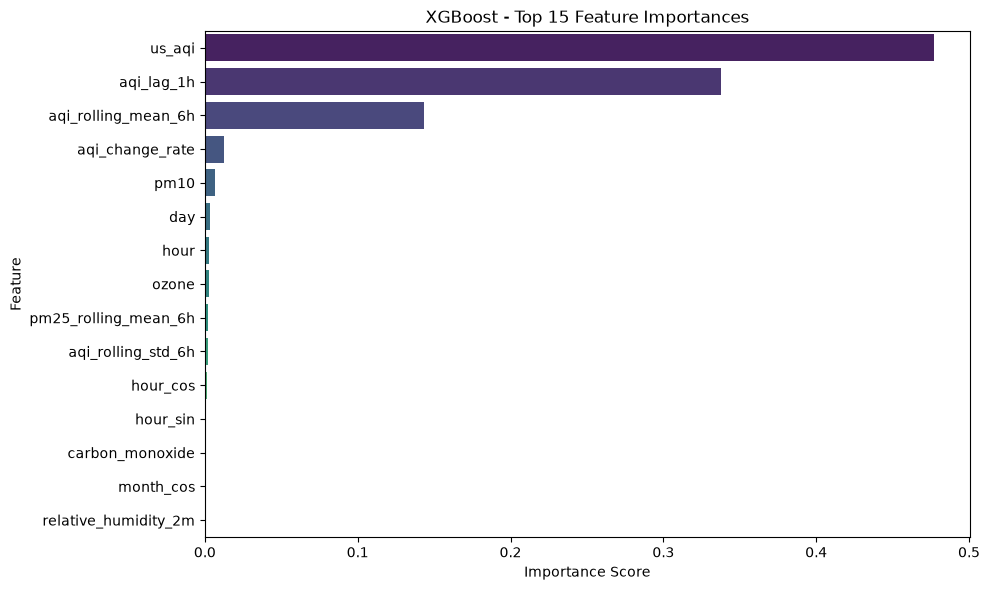

Plot saved.


In [15]:
xgb_importance = pd.DataFrame({
    "feature"   : FEATURE_COLUMNS,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("XGBoost Top 15 Features:")
display(xgb_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=xgb_importance.head(15),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("XGBoost - Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("data/processed/lahore/xgb_feature_importance.png", dpi=150)
plt.show()
print("Plot saved.")

In [16]:
# LSTM requires:
# 1. Scaled data (MinMaxScaler)
# 2. 3D input: (samples, timesteps, features)

print("Preparing data for LSTM...")

# Step 1: Scale features
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Fit ONLY on training data to prevent data leakage
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1, 1)
)
y_val_scaled = scaler_y.transform(
    y_val.values.reshape(-1, 1)
)
y_test_scaled = scaler_y.transform(
    y_test.values.reshape(-1, 1)
)

print("Scaling complete.")
print("X_train_scaled shape:", X_train_scaled.shape)

Preparing data for LSTM...
Scaling complete.
X_train_scaled shape: (15824, 29)


In [17]:
def create_sequences(X, y, timesteps=24):
    """
    Convert tabular data into LSTM sequences.

    For each position i, use the previous
    `timesteps` rows as input to predict
    the target at position i.

    Parameters
    ----------
    X         : np.ndarray, shape (n, features)
    y         : np.ndarray, shape (n, 1)
    timesteps : int, number of past hours to look back

    Returns
    -------
    X_seq : np.ndarray, shape (n - timesteps, timesteps, features)
    y_seq : np.ndarray, shape (n - timesteps,)
    """
    X_seq = []
    y_seq = []

    for i in range(timesteps, len(X)):
        X_seq.append(X[i - timesteps : i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)


# Use 24 hours of history
TIMESTEPS = 24
N_FEATURES = X_train_scaled.shape[1]

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    TIMESTEPS
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val_scaled,
    TIMESTEPS
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    TIMESTEPS
)

print("LSTM sequences created.")
print("X_train_seq shape:", X_train_seq.shape)
print("X_val_seq shape  :", X_val_seq.shape)
print("X_test_seq shape :", X_test_seq.shape)

# (samples, timesteps, features)
# This is the expected LSTM input shape

LSTM sequences created.
X_train_seq shape: (15800, 24, 29)
X_val_seq shape  : (3367, 24, 29)
X_test_seq shape : (3368, 24, 29)


In [18]:
def build_lstm_model(timesteps, n_features):
    """
    Build a stacked LSTM model for AQI forecasting.

    Architecture
    ------------
    LSTM(128) → Dropout(0.2) → BatchNorm
    LSTM(64)  → Dropout(0.2) → BatchNorm
    Dense(32) → Dense(1)
    """
    model = Sequential([

        # First LSTM layer
        # return_sequences=True because the next
        # layer is also LSTM
        LSTM(
            units=128,
            return_sequences=True,
            input_shape=(timesteps, n_features)
        ),
        Dropout(0.2),
        BatchNormalization(),

        # Second LSTM layer
        # return_sequences=False because next
        # layer is Dense
        LSTM(
            units=64,
            return_sequences=False
        ),
        Dropout(0.2),
        BatchNormalization(),

        # Fully connected layers
        Dense(units=32, activation="relu"),
        Dropout(0.1),

        # Output: single AQI value
        Dense(units=1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="huber",        # Huber is robust to AQI outliers
        metrics=["mae"]
    )

    return model


lstm_model = build_lstm_model(TIMESTEPS, N_FEATURES)

lstm_model.summary()

2026-08-18 21:33:06,296 WARNING: TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        80,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,185 (520.25 KB)

 Trainable params: 132,801 (518.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [19]:
# Create folder for LSTM checkpoint
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

lstm_checkpoint_path = str(
    MODEL_DIR / "lstm_best_checkpoint.keras"
)

callbacks = [

    # Stop training when val_loss stops improving
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # Save the best model weights during training
    ModelCheckpoint(
        filepath=lstm_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured.")
print("Checkpoint path:", lstm_checkpoint_path)

Callbacks configured.
Checkpoint path: models\lstm_best_checkpoint.keras


In [20]:
print("Training LSTM model...")
print()

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print("\nLSTM training complete.")
print("Best epoch:", np.argmin(history.history["val_loss"]) + 1)

Training LSTM model...

Epoch 1/100
246/247 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0899 - mae: 0.3126
Epoch 1: val_loss improved from None to 0.01572, saving model to models\lstm_best_checkpoint.keras

Epoch 1: finished saving model to models\lstm_best_checkpoint.keras
247/247 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - loss: 0.0896 - mae: 0.3122 - val_loss: 0.0157 - val_mae: 0.1522 - learning_rate: 0.0010
Epoch 2/100
246/247 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0184 - mae: 0.1483
Epoch 2: val_loss improved from 0.01572 to 0.00810, saving model to models\lstm_best_checkpoint.keras

Epoch 2: finished saving model to models\lstm_best_checkpoint.keras
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 0.0184 - mae: 0.1483 - val_loss: 0.0081 - val_mae: 0.1093 - learning_rate: 0.0010
Epoch 3/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0086 - mae: 0.1018
Epoch 3: val_loss improved from 0.00810 to 0.00348, saving model to models\lstm_best_checkpoint.keras

Epoch 3: finished s

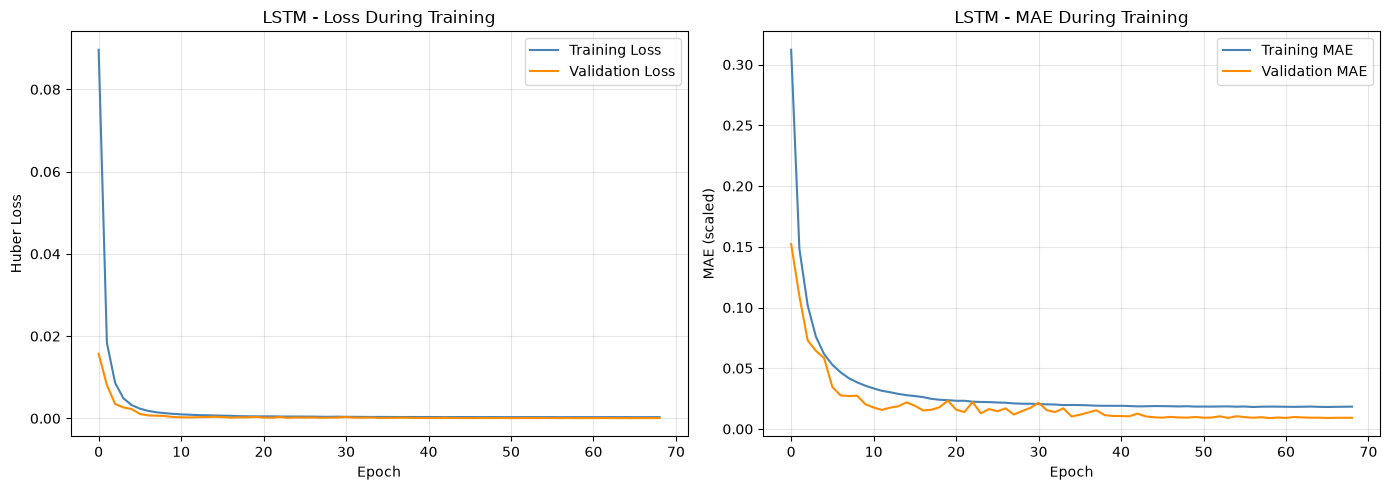

Training history plot saved.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(
    history.history["loss"],
    label="Training Loss",
    color="steelblue"
)
axes[0].plot(
    history.history["val_loss"],
    label="Validation Loss",
    color="darkorange"
)
axes[0].set_title("LSTM - Loss During Training")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Huber Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(
    history.history["mae"],
    label="Training MAE",
    color="steelblue"
)
axes[1].plot(
    history.history["val_mae"],
    label="Validation MAE",
    color="darkorange"
)
axes[1].set_title("LSTM - MAE During Training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (scaled)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "data/processed/lahore/lstm_training_history.png",
    dpi=150
)
plt.show()

print("Training history plot saved.")

In [23]:
print("Generating LSTM predictions...")

# Predict in scaled space
lstm_val_pred_scaled  = lstm_model.predict(X_val_seq, verbose=0)
lstm_test_pred_scaled = lstm_model.predict(X_test_seq, verbose=0)

# Inverse transform back to actual AQI values
lstm_val_pred  = scaler_y.inverse_transform(lstm_val_pred_scaled).flatten()
lstm_test_pred = scaler_y.inverse_transform(lstm_test_pred_scaled).flatten()

# Also inverse transform the actual y values
# (we need to align with sequence offset)
y_val_actual  = scaler_y.inverse_transform(
    y_val_seq.reshape(-1, 1)
).flatten()

y_test_actual = scaler_y.inverse_transform(
    y_test_seq.reshape(-1, 1)
).flatten()

print("Predictions generated.")
print("Val predictions shape :", lstm_val_pred.shape)
print("Test predictions shape:", lstm_test_pred.shape)

Generating LSTM predictions...
Predictions generated.
Val predictions shape : (3367,)
Test predictions shape: (3368,)


In [24]:
lstm_val_result = evaluate_model(
    y_val_actual,
    lstm_val_pred,
    "LSTM",
    "Validation"
)

lstm_test_result = evaluate_model(
    y_test_actual,
    lstm_test_pred,
    "LSTM",
    "Test"
)

all_results.append(lstm_val_result)

print("LSTM evaluation complete.")


Model  : LSTM | Dataset: Validation
MAE    : 4.3263
RMSE   : 5.7691
R²     : 0.9819

Model  : LSTM | Dataset: Test
MAE    : 6.0795
RMSE   : 8.8611
R²     : 0.9531
LSTM evaluation complete.


In [25]:
print("\n")
print("=" * 70)
print("COMPLETE MODEL COMPARISON - VALIDATION SET")
print("=" * 70)

comparison_df = pd.DataFrame(all_results)

comparison_df = (
    comparison_df
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(comparison_df)

print("=" * 70)
print("Best model by RMSE:", comparison_df.iloc[0]["Model"])
print("=" * 70)



COMPLETE MODEL COMPARISON - VALIDATION SET


,Model,Dataset,MAE,RMSE,R2
0,Ridge Regression,Validation,1.0044,1.5177,0.9988
1,Baseline (Persistence),Validation,1.1930,1.8827,0.9981
2,XGBoost,Validation,1.0790,2.4960,0.9966
3,Random Forest,Validation,1.6369,2.6725,0.9961
4,LSTM,Validation,4.3263,5.7691,0.9819


Best model by RMSE: Ridge Regression


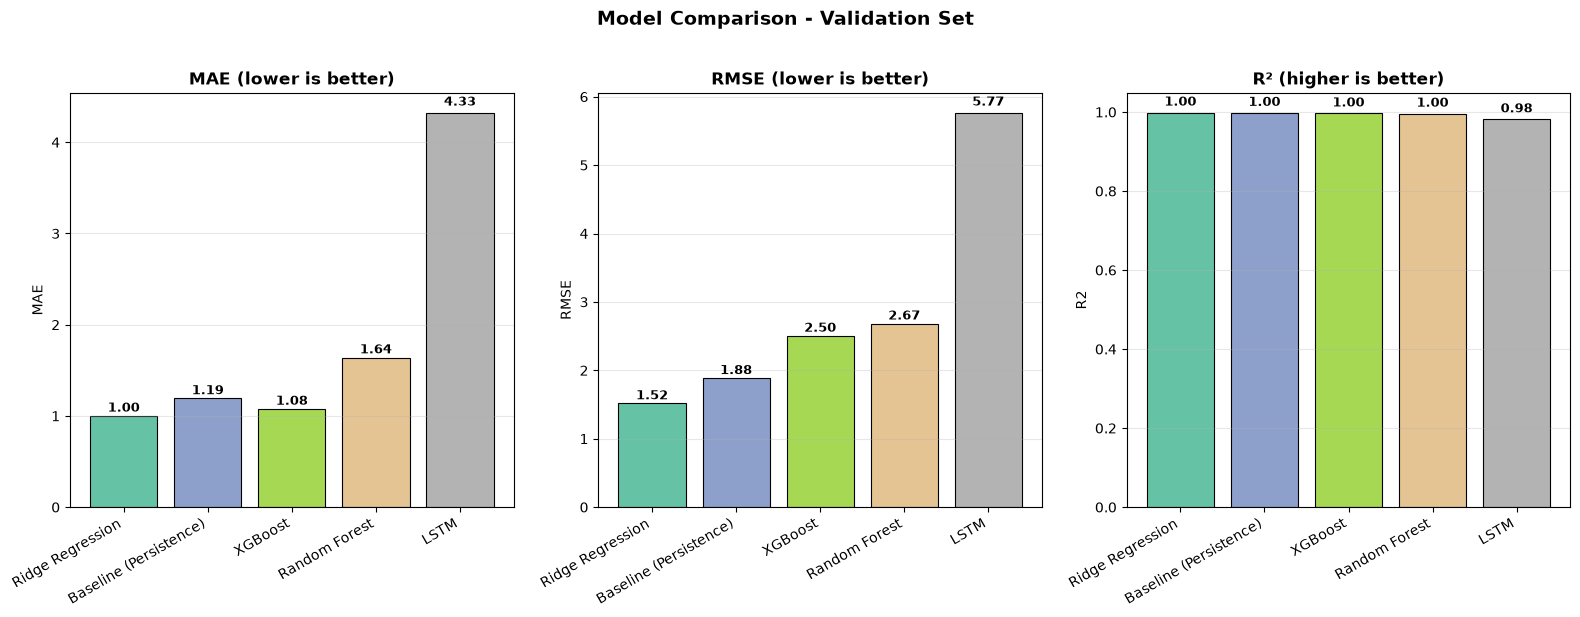

Comparison chart saved.


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

models     = comparison_df["Model"]
colors     = plt.cm.Set2(np.linspace(0, 1, len(models)))

metrics = [
    ("MAE",  "MAE (lower is better)",  axes[0]),
    ("RMSE", "RMSE (lower is better)", axes[1]),
    ("R2",   "R² (higher is better)",  axes[2])
]

for metric, title, ax in metrics:
    bars = ax.bar(
        models,
        comparison_df[metric],
        color=colors,
        edgecolor="black",
        linewidth=0.8
    )

    # Add value labels on bars
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01 * bar.get_height(),
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_xticklabels(models, rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Model Comparison - Validation Set",
    fontsize=14,
    fontweight="bold",
    y=1.02
)
plt.tight_layout()
plt.savefig(
    "data/processed/lahore/model_comparison_validation.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
print("Comparison chart saved.")

In [27]:
# Best model is determined by lowest RMSE on validation set
best_model_name = comparison_df.iloc[0]["Model"]

print("=" * 60)
print(f"BEST MODEL: {best_model_name}")
print("=" * 60)

# Map name to actual model object
model_map = {
    "Baseline (Persistence)": None,
    "Ridge Regression"      : ridge,
    "Random Forest"         : rf,
    "XGBoost"               : xgb_model,
    "LSTM"                  : lstm_model
}

best_model = model_map[best_model_name]

print("Best model object:", type(best_model))

BEST MODEL: Ridge Regression
Best model object: <class 'sklearn.linear_model._ridge.Ridge'>


In [28]:
print(f"\nFinal Test Evaluation: {best_model_name}")
print("=" * 60)

# Select the correct test predictions
test_pred_map = {
    "Baseline (Persistence)": baseline_test_pred,
    "Ridge Regression"      : ridge_test_pred,
    "Random Forest"         : rf_test_pred,
    "XGBoost"               : xgb_test_pred,
    "LSTM"                  : lstm_test_pred
}

# Select correct y_test
# LSTM has fewer rows due to sequence offset
if best_model_name == "LSTM":
    final_y_test    = y_test_actual
    final_test_pred = test_pred_map[best_model_name]
else:
    final_y_test    = y_test.values
    final_test_pred = test_pred_map[best_model_name]

final_test_result = evaluate_model(
    final_y_test,
    final_test_pred,
    best_model_name,
    "TEST (Final)"
)

print("\nFinal test result:")
display(pd.DataFrame([final_test_result]))


Final Test Evaluation: Ridge Regression

Model  : Ridge Regression | Dataset: TEST (Final)
MAE    : 2.8946
RMSE   : 4.6925
R²     : 0.9868

Final test result:


,Model,Dataset,MAE,RMSE,R2
0,Ridge Regression,TEST (Final),2.8946,4.6925,0.9868


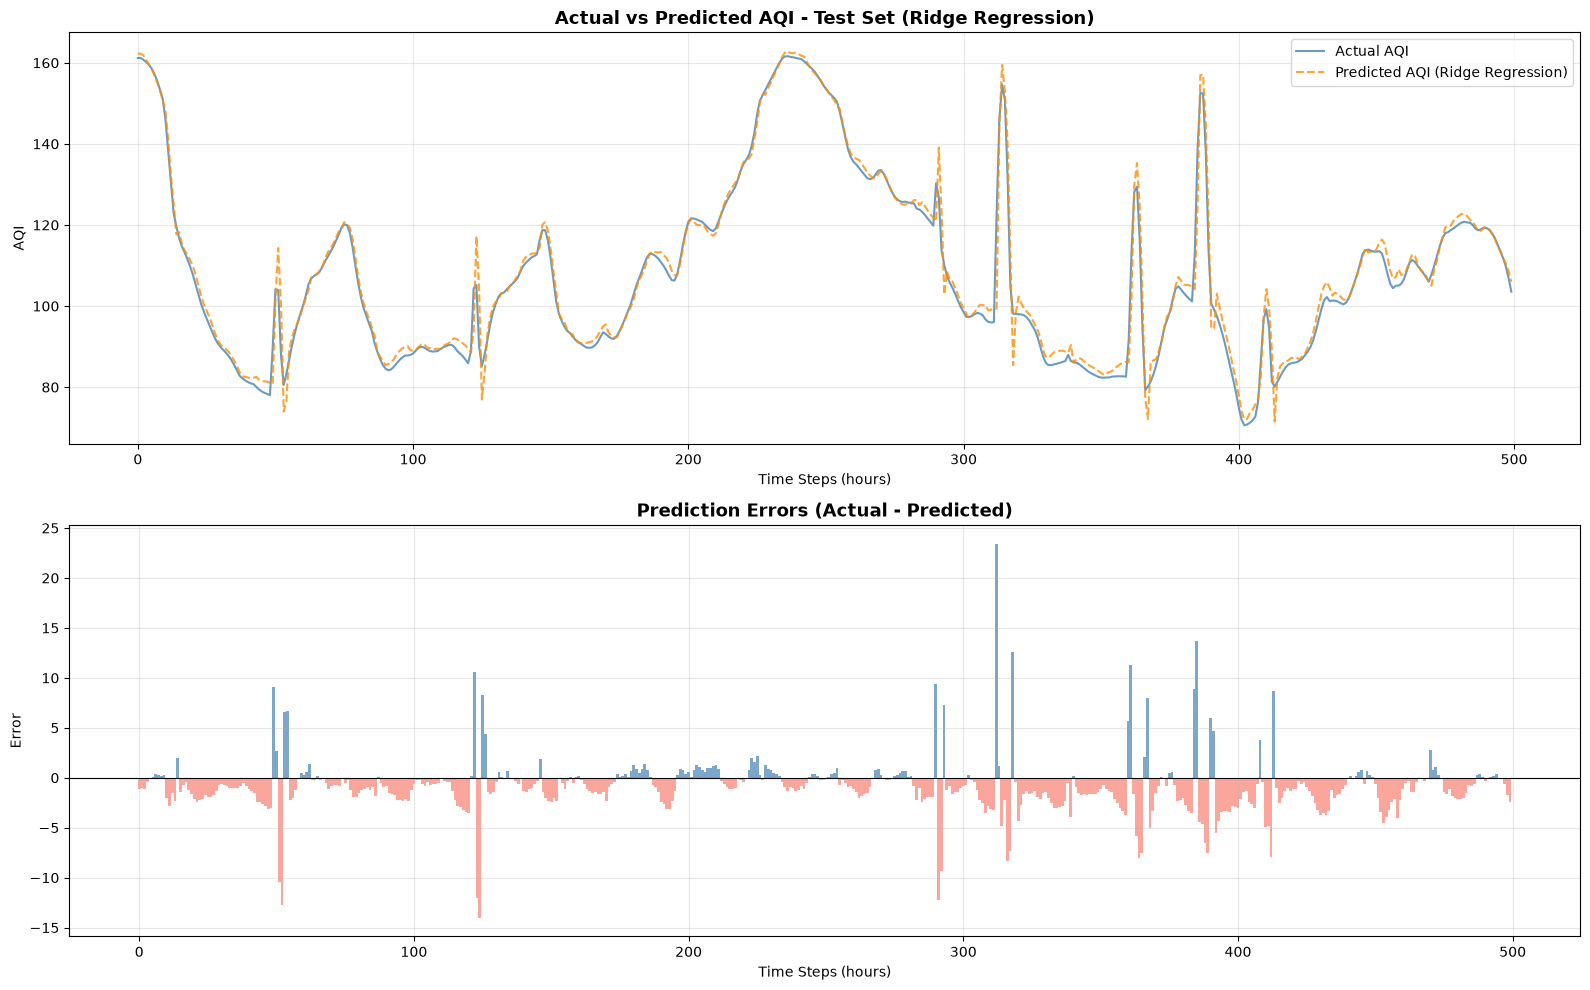

Test result plot saved.


In [29]:
PLOT_POINTS = 500

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Actual vs Predicted
axes[0].plot(
    final_y_test[:PLOT_POINTS],
    label="Actual AQI",
    color="steelblue",
    linewidth=1.5,
    alpha=0.8
)
axes[0].plot(
    final_test_pred[:PLOT_POINTS],
    label=f"Predicted AQI ({best_model_name})",
    color="darkorange",
    linewidth=1.5,
    alpha=0.8,
    linestyle="--"
)
axes[0].set_title(
    f"Actual vs Predicted AQI - Test Set ({best_model_name})",
    fontsize=13,
    fontweight="bold"
)
axes[0].set_xlabel("Time Steps (hours)")
axes[0].set_ylabel("AQI")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Prediction Errors
errors = final_y_test[:PLOT_POINTS] - final_test_pred[:PLOT_POINTS]

axes[1].bar(
    range(len(errors)),
    errors,
    color=np.where(errors >= 0, "steelblue", "salmon"),
    alpha=0.7,
    width=1.0
)
axes[1].axhline(y=0, color="black", linewidth=0.8)
axes[1].set_title(
    "Prediction Errors (Actual - Predicted)",
    fontsize=13,
    fontweight="bold"
)
axes[1].set_xlabel("Time Steps (hours)")
axes[1].set_ylabel("Error")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "data/processed/lahore/best_model_test_results.png",
    dpi=150
)
plt.show()
print("Test result plot saved.")

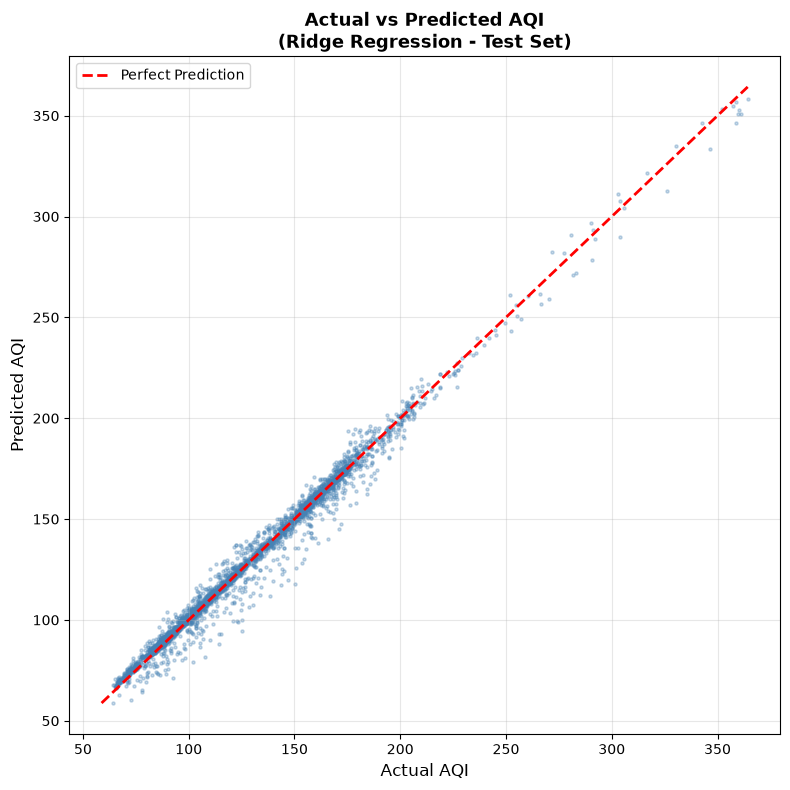

Scatter plot saved.


In [30]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    final_y_test,
    final_test_pred,
    alpha=0.3,
    s=5,
    color="steelblue"
)

# Perfect prediction line
min_val = min(final_y_test.min(), final_test_pred.min())
max_val = max(final_y_test.max(), final_test_pred.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2,
    linestyle="--",
    label="Perfect Prediction"
)

ax.set_xlabel("Actual AQI", fontsize=12)
ax.set_ylabel("Predicted AQI", fontsize=12)
ax.set_title(
    f"Actual vs Predicted AQI\n({best_model_name} - Test Set)",
    fontsize=13,
    fontweight="bold"
)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "data/processed/lahore/scatter_actual_vs_predicted.png",
    dpi=150
)
plt.show()
print("Scatter plot saved.")

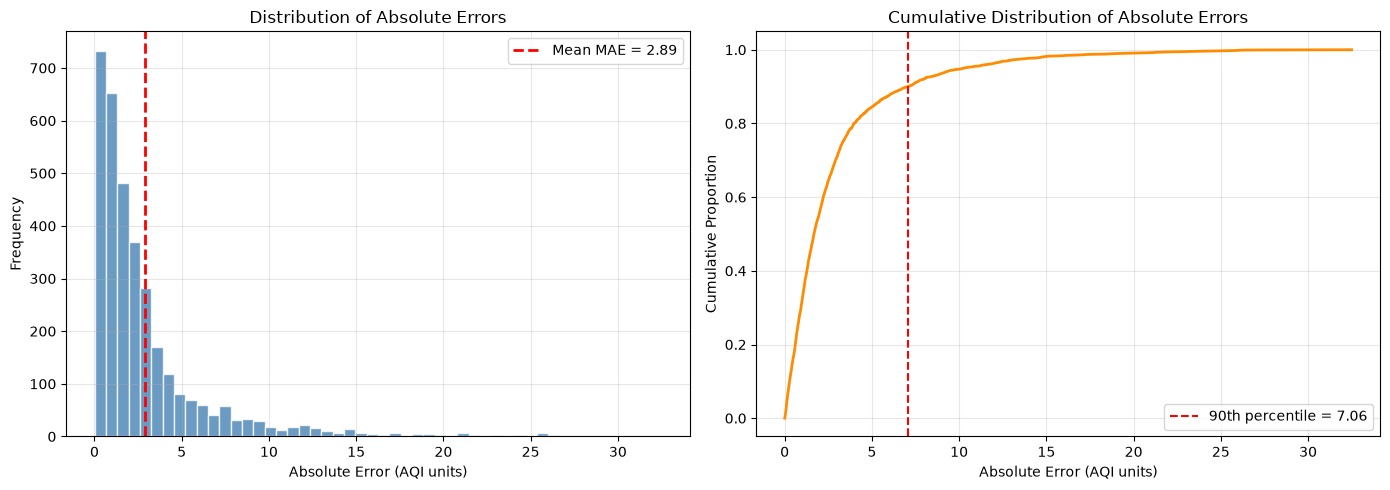

90% of predictions are within 7.06 AQI units
95% of predictions are within 10.26 AQI units


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

abs_errors = np.abs(final_y_test - final_test_pred)

# Histogram
axes[0].hist(
    abs_errors,
    bins=50,
    color="steelblue",
    edgecolor="white",
    alpha=0.8
)
axes[0].axvline(
    x=abs_errors.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean MAE = {abs_errors.mean():.2f}"
)
axes[0].set_title("Distribution of Absolute Errors")
axes[0].set_xlabel("Absolute Error (AQI units)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CDF
sorted_errors = np.sort(abs_errors)
cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

axes[1].plot(sorted_errors, cdf, color="darkorange", linewidth=2)
axes[1].axvline(
    x=np.percentile(abs_errors, 90),
    color="red",
    linestyle="--",
    label=f"90th percentile = {np.percentile(abs_errors, 90):.2f}"
)
axes[1].set_title("Cumulative Distribution of Absolute Errors")
axes[1].set_xlabel("Absolute Error (AQI units)")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "data/processed/lahore/error_distribution.png",
    dpi=150
)
plt.show()

print(f"90% of predictions are within {np.percentile(abs_errors, 90):.2f} AQI units")
print(f"95% of predictions are within {np.percentile(abs_errors, 95):.2f} AQI units")

In [32]:
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Ridge
joblib.dump(ridge, MODEL_DIR / "ridge_aqi_1h.pkl")
print("Saved: ridge_aqi_1h.pkl")

# Random Forest
joblib.dump(rf, MODEL_DIR / "random_forest_aqi_1h.pkl")
print("Saved: random_forest_aqi_1h.pkl")

# XGBoost
xgb_model.save_model(str(MODEL_DIR / "xgboost_aqi_1h.json"))
print("Saved: xgboost_aqi_1h.json")

# LSTM
lstm_model.save(str(MODEL_DIR / "lstm_aqi_1h.keras"))
print("Saved: lstm_aqi_1h.keras")

# Scalers (LSTM needs these for prediction)
joblib.dump(scaler_X, MODEL_DIR / "scaler_X.pkl")
joblib.dump(scaler_y, MODEL_DIR / "scaler_y.pkl")
print("Saved: scaler_X.pkl, scaler_y.pkl")

print("\nAll models saved to:", MODEL_DIR)

Saved: ridge_aqi_1h.pkl
Saved: random_forest_aqi_1h.pkl
Saved: xgboost_aqi_1h.json
Saved: lstm_aqi_1h.keras
Saved: scaler_X.pkl, scaler_y.pkl

All models saved to: models


In [34]:
RESULTS_DIR = Path("../data/processed/lahore")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Full comparison
comparison_df.to_csv(
    RESULTS_DIR / "model_comparison_validation.csv",
    index=False
)

# Final test result
pd.DataFrame([final_test_result]).to_csv(
    RESULTS_DIR / "best_model_test_result.csv",
    index=False
)

# Test predictions
if best_model_name == "LSTM":
    datetime_test = lahore_features["datetime"].iloc[
        val_end + TIMESTEPS:
    ].values
else:
    datetime_test = lahore_features["datetime"].iloc[
        val_end:
    ].values

test_pred_df = pd.DataFrame({
    "datetime"     : datetime_test,
    "actual_aqi"   : final_y_test,
    "predicted_aqi": final_test_pred,
    "error"        : final_y_test - final_test_pred,
    "abs_error"    : np.abs(final_y_test - final_test_pred)
})

test_pred_df.to_csv(
    RESULTS_DIR / "test_predictions.csv",
    index=False
)

print("Results saved:")
print("  model_comparison_validation.csv")
print("  best_model_test_result.csv")
print("  test_predictions.csv")

Results saved:
  model_comparison_validation.csv
  best_model_test_result.csv
  test_predictions.csv


In [35]:
print("\n")
print("=" * 70)
print("TRAINING COMPLETE — FINAL SUMMARY")
print("=" * 70)

print("\nModel Comparison (Validation Set):")
display(comparison_df)

print(f"\nBest Model        : {best_model_name}")
print(f"Final Test MAE    : {final_test_result['MAE']:.4f}")
print(f"Final Test RMSE   : {final_test_result['RMSE']:.4f}")
print(f"Final Test R²     : {final_test_result['R2']:.4f}")

print("\nSaved Files:")
print("  models/ridge_aqi_1h.pkl")
print("  models/random_forest_aqi_1h.pkl")
print("  models/xgboost_aqi_1h.json")
print("  models/lstm_aqi_1h.keras")
print("  models/scaler_X.pkl")
print("  models/scaler_y.pkl")
print("  data/processed/lahore/model_comparison_validation.csv")
print("  data/processed/lahore/best_model_test_result.csv")
print("  data/processed/lahore/test_predictions.csv")

print("\nNext Step:")
print("  07_model_registry.ipynb")
print("  Register best model in Hopsworks Model Registry")
print("=" * 70)



TRAINING COMPLETE — FINAL SUMMARY

Model Comparison (Validation Set):


,Model,Dataset,MAE,RMSE,R2
0,Ridge Regression,Validation,1.0044,1.5177,0.9988
1,Baseline (Persistence),Validation,1.1930,1.8827,0.9981
2,XGBoost,Validation,1.0790,2.4960,0.9966
3,Random Forest,Validation,1.6369,2.6725,0.9961
4,LSTM,Validation,4.3263,5.7691,0.9819



Best Model        : Ridge Regression
Final Test MAE    : 2.8946
Final Test RMSE   : 4.6925
Final Test R²     : 0.9868

Saved Files:
  models/ridge_aqi_1h.pkl
  models/random_forest_aqi_1h.pkl
  models/xgboost_aqi_1h.json
  models/lstm_aqi_1h.keras
  models/scaler_X.pkl
  models/scaler_y.pkl
  data/processed/lahore/model_comparison_validation.csv
  data/processed/lahore/best_model_test_result.csv
  data/processed/lahore/test_predictions.csv

Next Step:
  07_model_registry.ipynb
  Register best model in Hopsworks Model Registry
